##1. Limpieza de Datos:
* **Identificación y eliminación de valores duplicados:** Asegúrate de que no haya registros duplicados que puedan sesgar los resultados del análisis.
* **Verificación y ajuste de tipos de datos:** Verifica que cada columna tenga el tipo de dato correcto (numérico o categórico) y ajusta si es necesario.
* **Corrección de inconsistencias en valores categóricos:** Revisa las categorías de las variables y unifica aquellos valores que puedan estar escritos de diferentes maneras pero que representen lo mismo.
* **Manejo de valores faltantes adecuadamente:** Identifica y maneja los valores faltantes utilizando técnicas apropiadas como la imputación de la mediana, media o moda, según corresponda.

**1.1 Identificación y eliminación de valores duplicados**

In [82]:
import pandas as pd

# Cargar el dataset desde un archivo CSV
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv'
wine_data = pd.read_csv(url, delimiter=';')

# Verificación de datos duplicados
print(f'Número de filas duplicadas: {wine_data.duplicated().sum()}')

# Eliminación de datos duplicados
wine_data.drop_duplicates(inplace=True)
print(f'Número de filas duplicadas después de eliminar: {wine_data.duplicated().sum()}')

# Mostrar las primeras filas del dataset
print("\nPrimeros registros:")
print(wine_data.head())

Número de filas duplicadas: 240
Número de filas duplicadas después de eliminar: 0

Primeros registros:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
5            7.4              0.66         0.00             1.8      0.075   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
5                 13.0                  40.0   0.9978  3.5

**1.2 Verificación y ajuste de tipos de datos**

In [83]:
# Verificación de tipos de datos
print(wine_data.dtypes)

fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object


**1.3 Corrección de inconsistencias en valores categóricos**

In [84]:
# Binarización de la columna 'quality' en una variable categórica para poder usar más adelante el Logistic Regression
# Si es mayor a 7 equivale a 1 y si es menor a 7 equivale a 0
wine_data['quality'] = wine_data['quality'].apply(lambda x: 1 if x >= 7 else 0)

# Verificación del cambio
print(wine_data['quality'].value_counts())

quality
0    1175
1     184
Name: count, dtype: int64


**1.4 Manejo de valores faltantes adecuadamente**

In [85]:
# Identificación de valores faltantes
# Identificar y manejar los valores faltantes utilizando técnicas apropiadas
missing_values = wine_data.isnull().sum()
print(f'Valores faltantes por columna:\n{missing_values}')

Valores faltantes por columna:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


##2. Exploración de Datos
* **Visualizaciones univariadas y multivariadas:** Crea histogramas, gráficos de barras, diagramas de dispersión y mapas de calor para entender la distribución y las relaciones entre las variables.
* **Estadísticas descriptivas:** Calcula medidas de tendencia central (media, mediana, moda) y de dispersión (rango, desviación estándar) para cada característica del dataset.

**2.1 Visualizaciones univariadas y multivariadas**

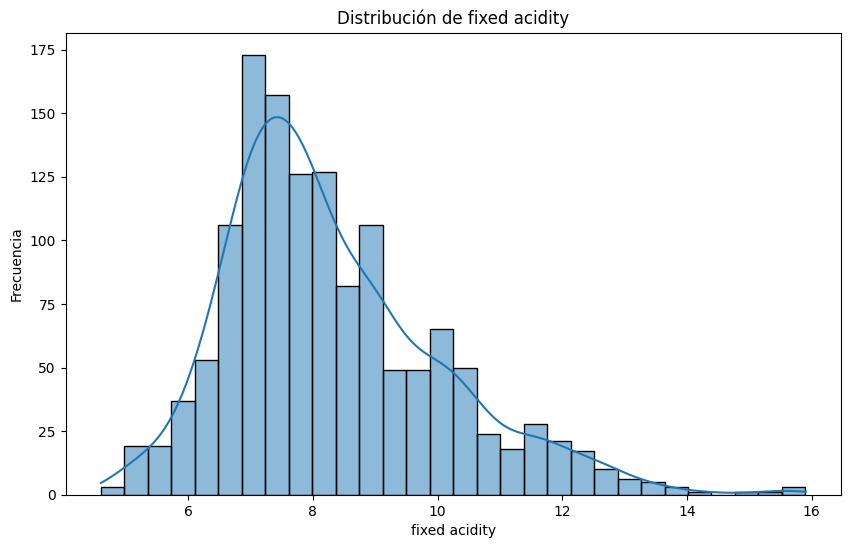

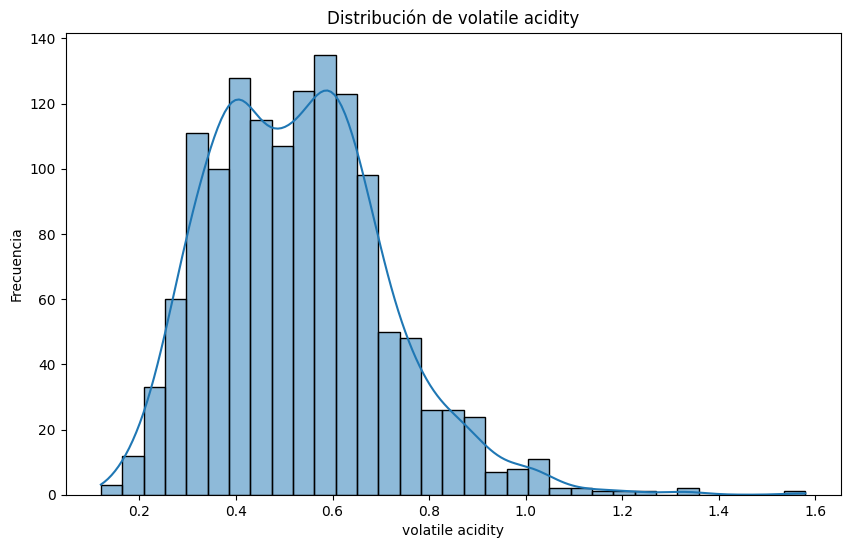

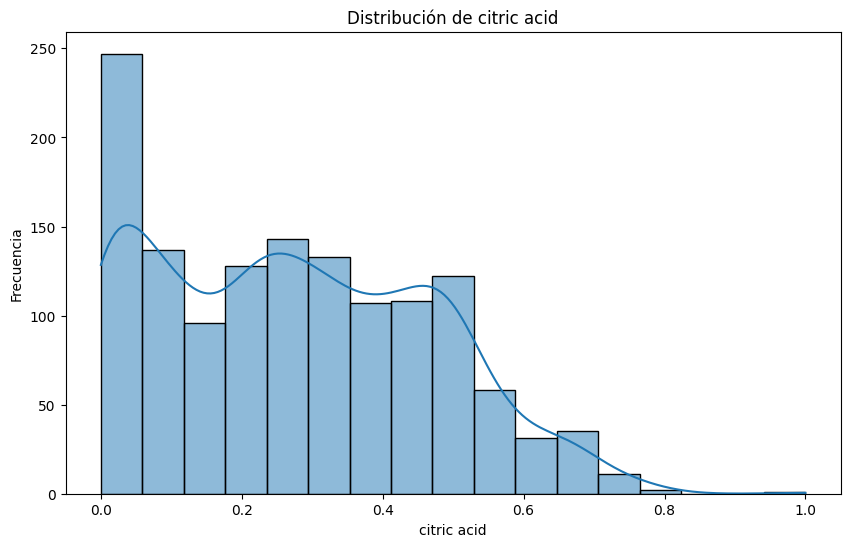

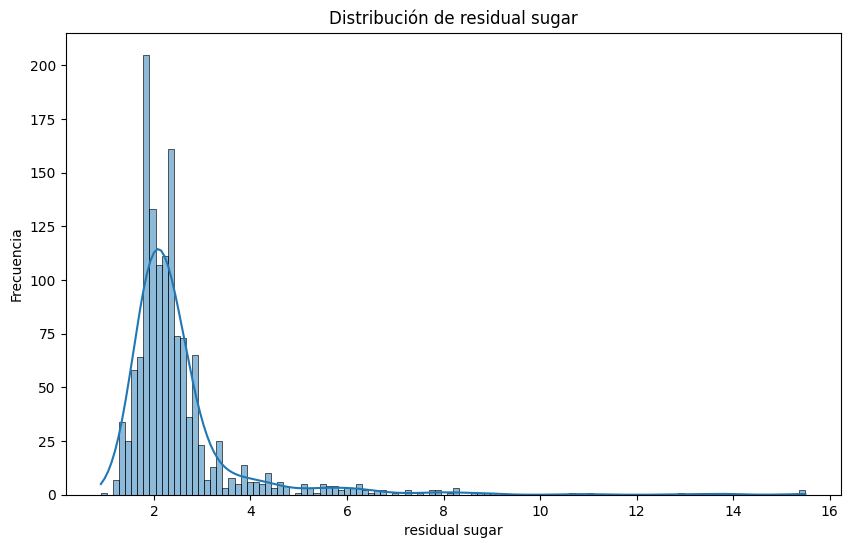

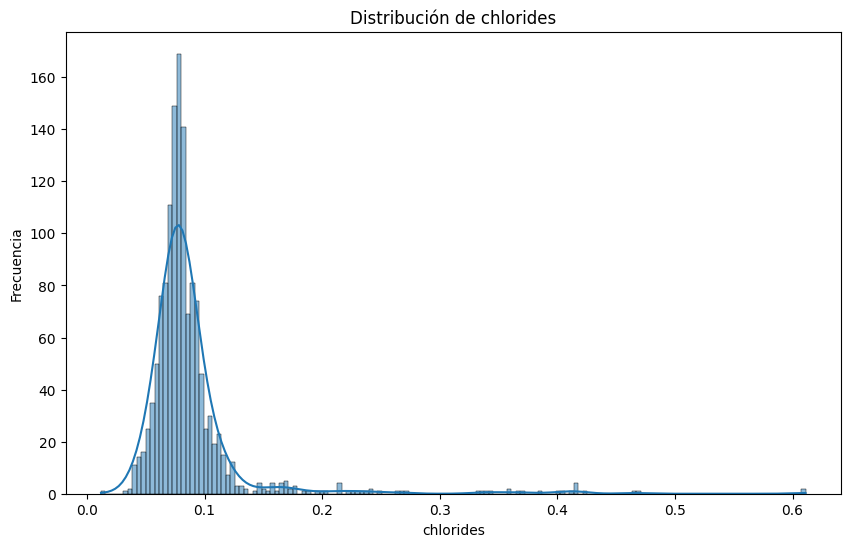

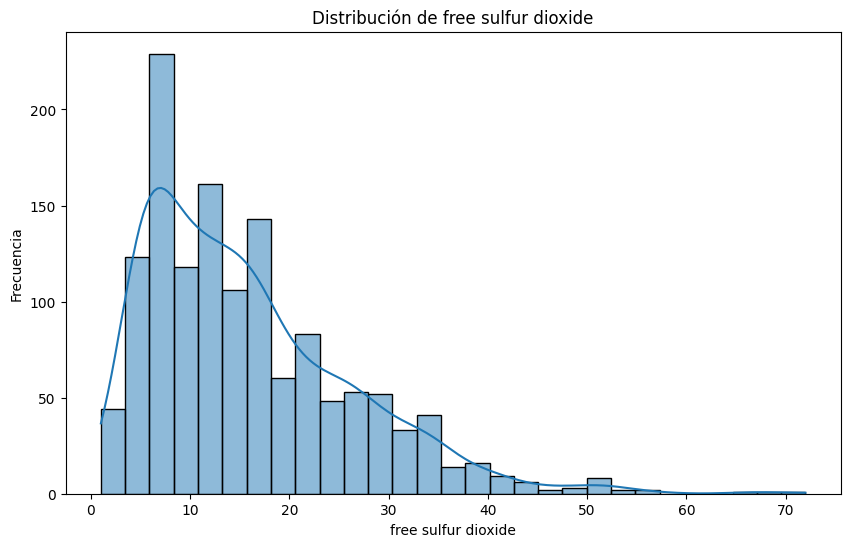

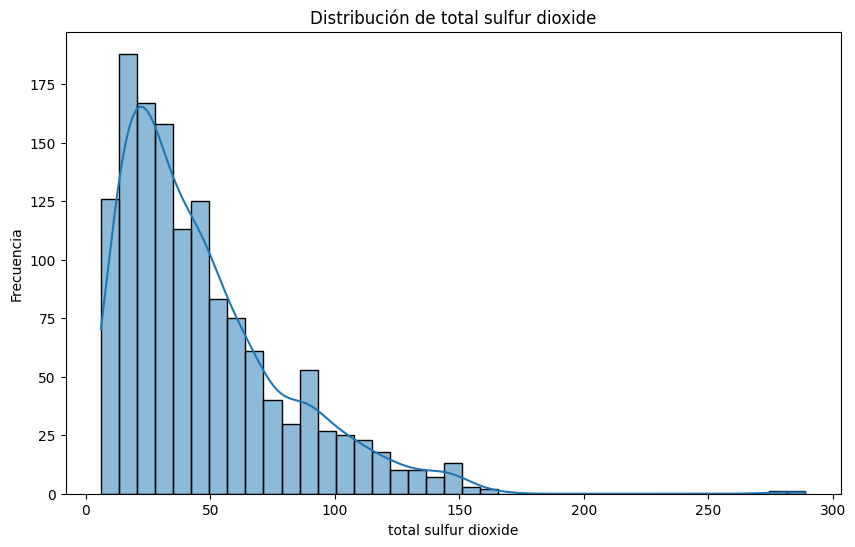

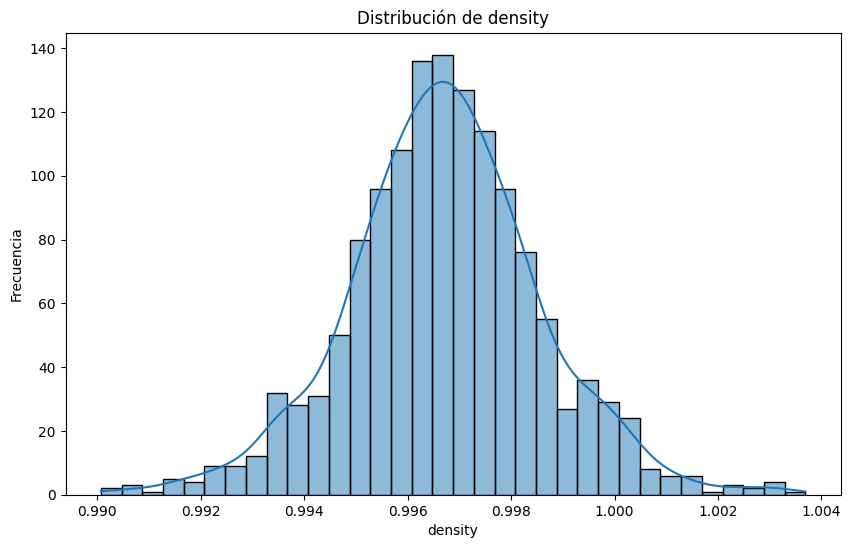

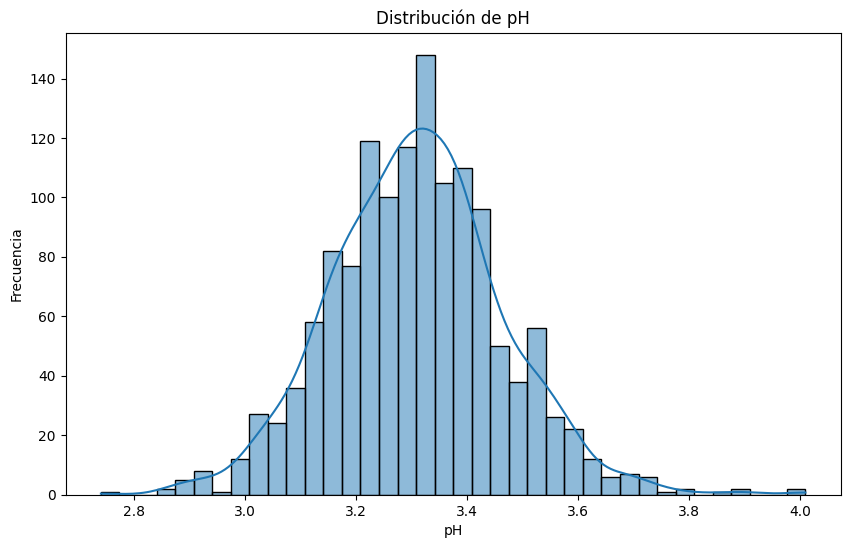

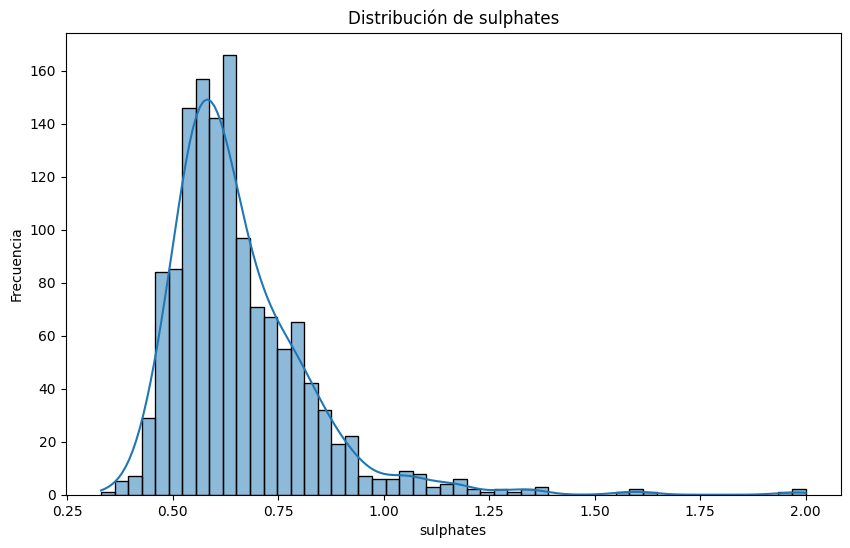

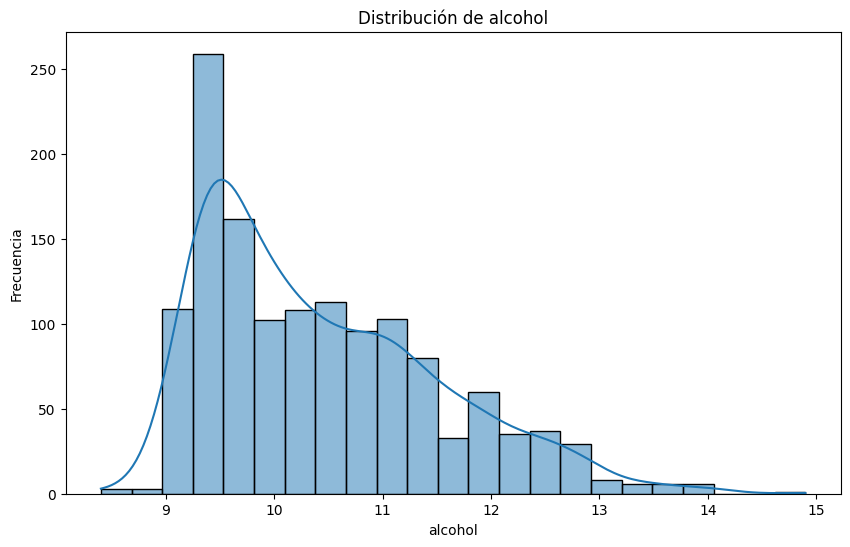

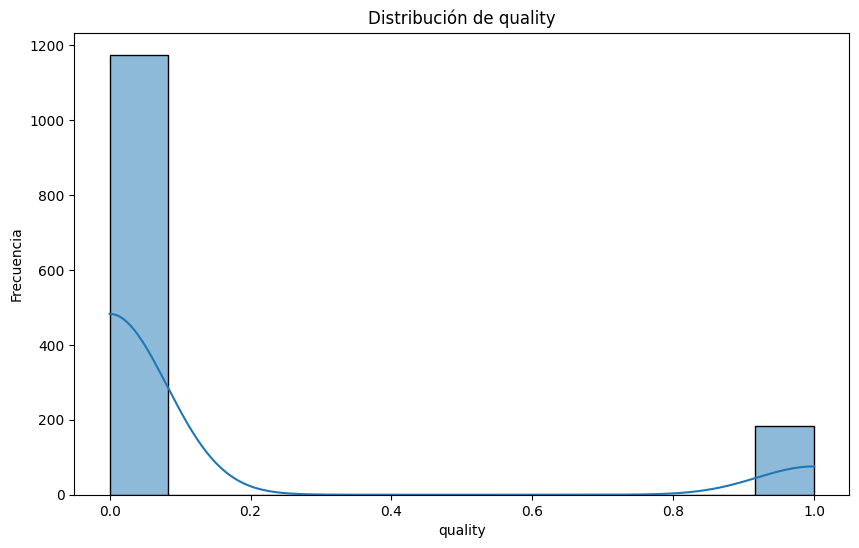

In [86]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histograma de cada variable
# Crear histogramas para entender la distribución de cada variable
for column in wine_data.columns:
    plt.figure(figsize=(10, 6))
    sns.histplot(wine_data[column], kde=True)
    plt.title(f'Distribución de {column}')
    plt.xlabel(column)
    plt.ylabel('Frecuencia')
    plt.show()

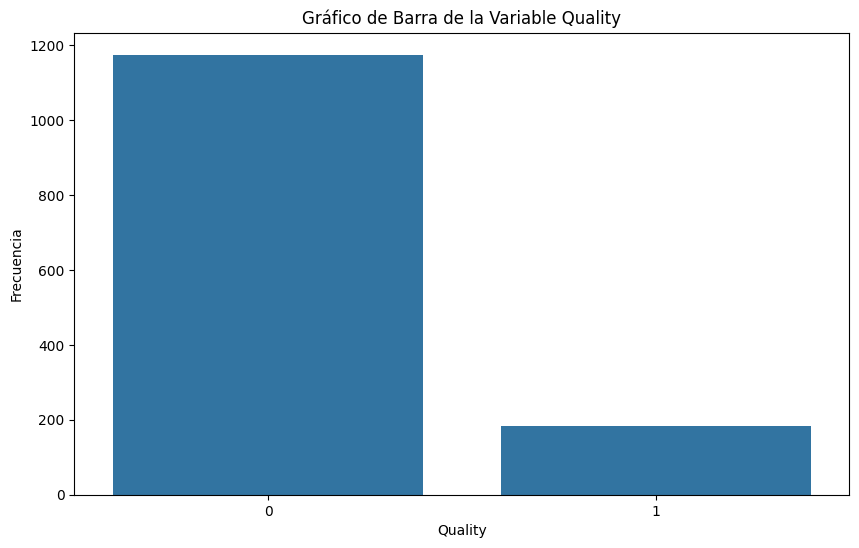

In [87]:
# Gráfico de barras para la variable 'quality'
# Crear un gráfico de barras para visualizar la distribución de la variable 'quality' después de la binarización
plt.figure(figsize=(10, 6))
sns.countplot(x='quality', data=wine_data)
plt.title('Gráfico de Barra de la Variable Quality')
plt.xlabel('Quality')
plt.ylabel('Frecuencia')
plt.show()

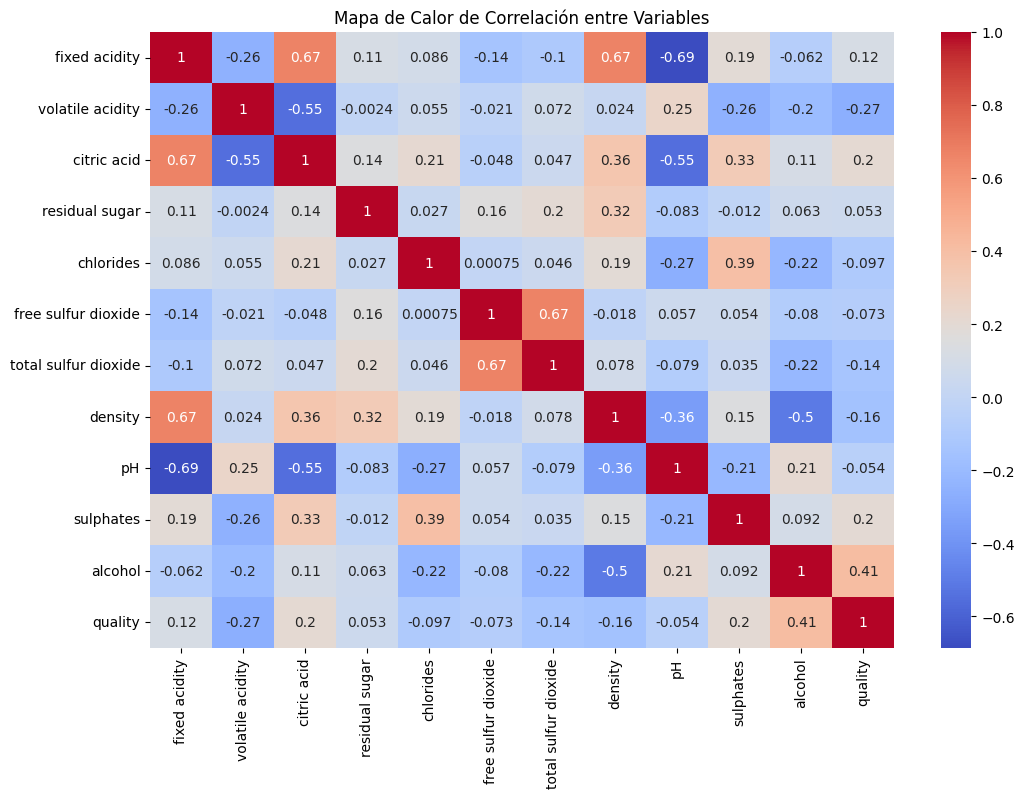

In [88]:
# Matriz de correlación y heatmap
# Crear un mapa de calor para visualizar las correlaciones entre las variables
correlation_matrix = wine_data.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Mapa de Calor de Correlación entre Variables')
plt.show()

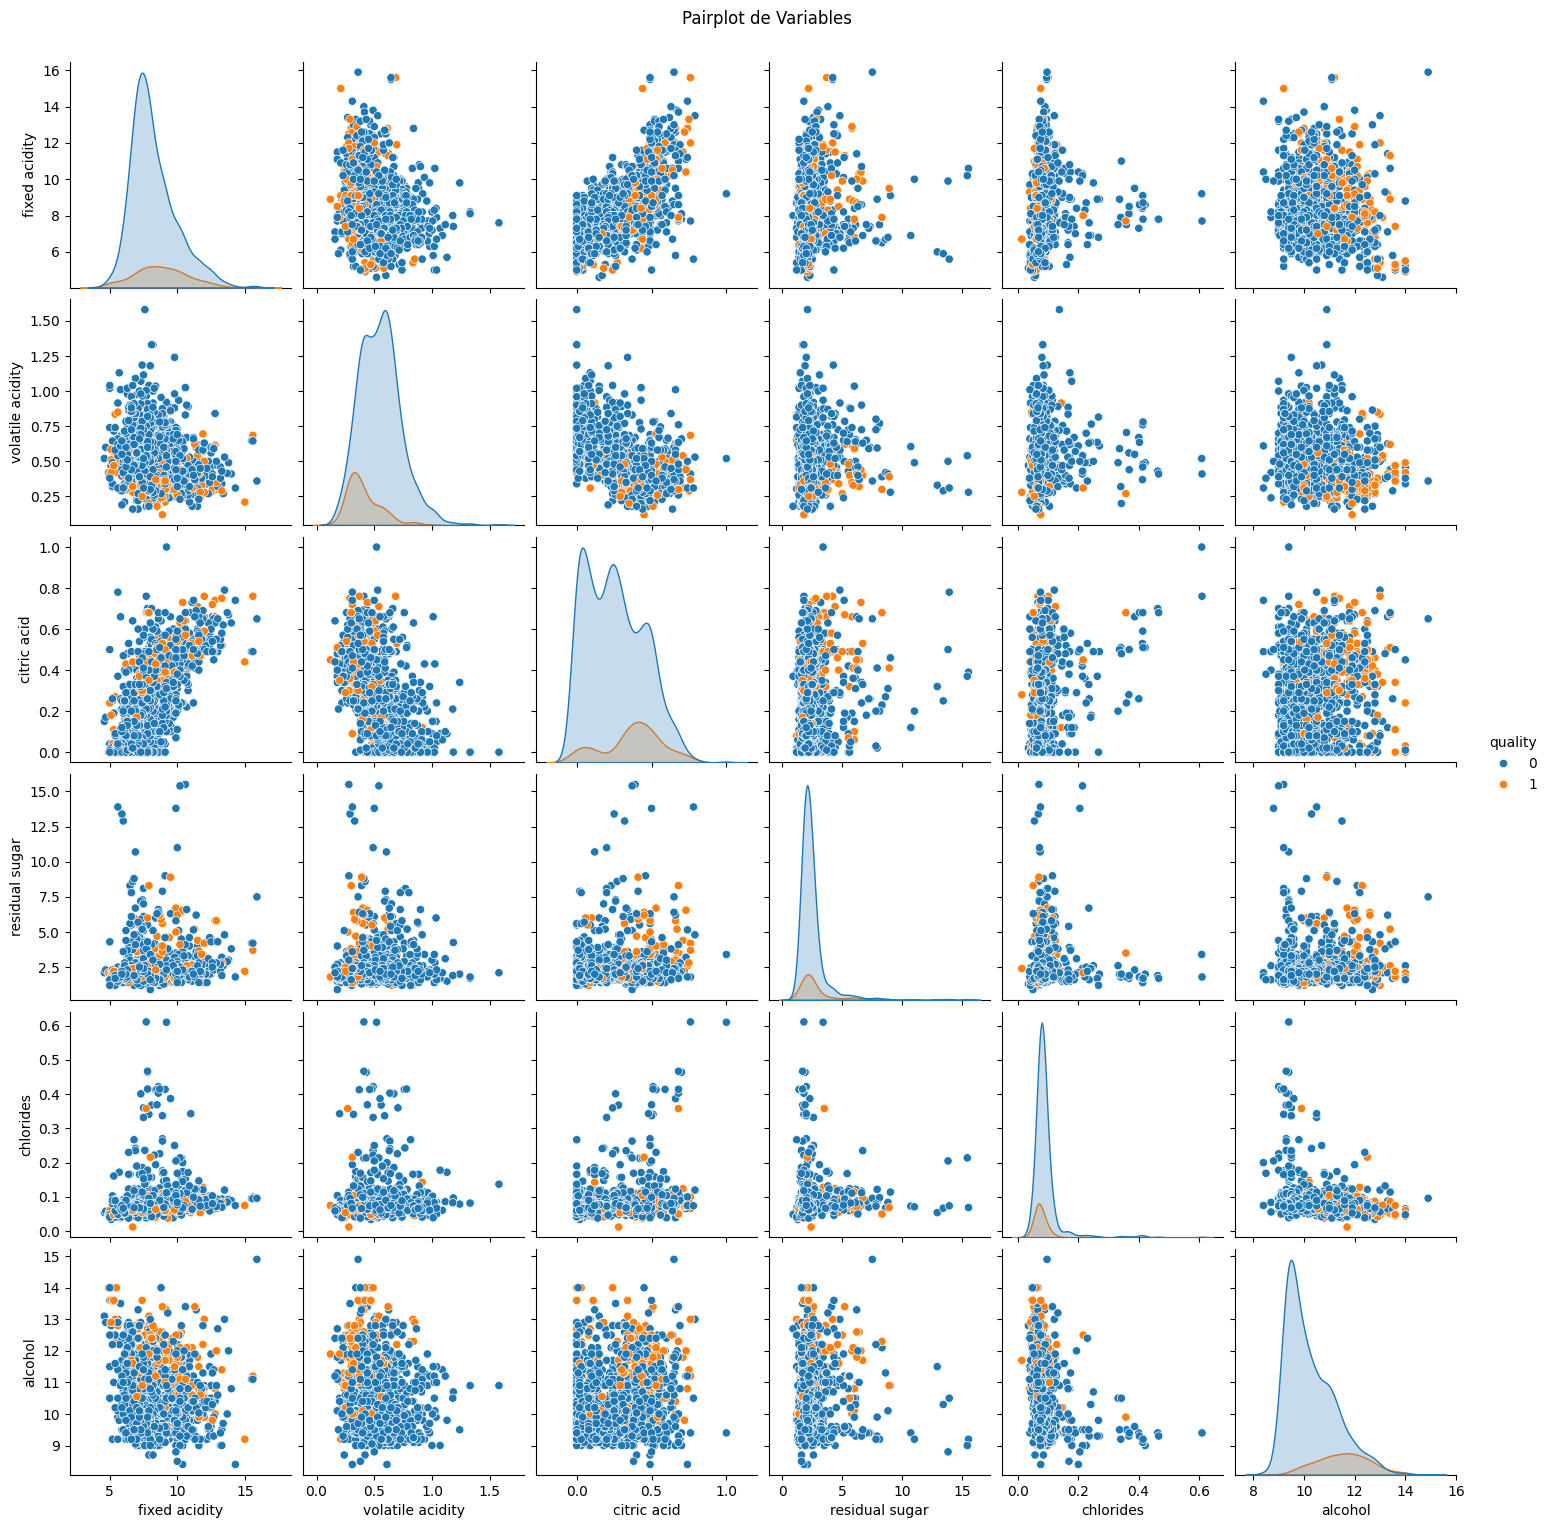

In [89]:
# Pairplot de variables
# Crear pairplots para visualizar relaciones entre un subconjunto de variables principales
main_features = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'alcohol', 'quality']
sns.pairplot(wine_data[main_features], hue='quality', diag_kind='kde')
plt.suptitle('Pairplot de Variables', y=1.02)
plt.show()

**2.2 Estadísticas descriptivas**

In [90]:
# Calcular medidas de tendencia central y dispersión para cada característica
medidas_tendencia_dispersión = pd.DataFrame({
    'Media': wine_data.mean(),
    'Mediana': wine_data.median(),
    'Moda': wine_data.mode().iloc[0],
    'Rango': wine_data.max() - wine_data.min(),
    'Desviación Estándar': wine_data.std()
})

print(medidas_tendencia_dispersión)

                          Media  Mediana     Moda      Rango  \
fixed acidity          8.310596   7.9000   7.2000   11.30000   
volatile acidity       0.529478   0.5200   0.5000    1.46000   
citric acid            0.272333   0.2600   0.0000    1.00000   
residual sugar         2.523400   2.2000   2.0000   14.60000   
chlorides              0.088124   0.0790   0.0800    0.59900   
free sulfur dioxide   15.893304  14.0000   6.0000   71.00000   
total sulfur dioxide  46.825975  38.0000  28.0000  283.00000   
density                0.996709   0.9967   0.9968    0.01362   
pH                     3.309787   3.3100   3.3000    1.27000   
sulphates              0.658705   0.6200   0.5400    1.67000   
alcohol               10.432315  10.2000   9.5000    6.50000   
quality                0.135394   0.0000   0.0000    1.00000   

                      Desviación Estándar  
fixed acidity                    1.736990  
volatile acidity                 0.183031  
citric acid                      0.

##3. Implementación de Modelos
* **Modelos de Clasificación:** Implementa modelos de Logistic Regression y K-Nearest Neighbors (KNN).
* **Evaluación de Modelos:** Evalúa los modelos utilizando métricas como accuracy, precision, recall, y F1-score.
* **Comparación de Rendimiento:** Compara los resultados de ambos modelos y discute cuál es el más adecuado para este dataset.

**3.1 Modelos de Clasificación: Logistic Regression y K-Nearest Neighbors (KNN)**

In [73]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Variables predictoras y objetivo
X = wine_data.drop(columns='quality')
y = wine_data['quality']

# Dividir en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Conjunto de entrenamiento: {X_train.shape}, Conjunto de prueba: {X_test.shape}")

Conjunto de entrenamiento: (1087, 11), Conjunto de prueba: (272, 11)


In [74]:
# Modelo de Logistic Regression con mejoras
# Escalar los datos y aplicar Logistic Regression con más iteraciones y solver diferente
log_reg_pipeline = make_pipeline(StandardScaler(), LogisticRegression(solver='liblinear', max_iter=5000))
log_reg_pipeline.fit(X_train, y_train)
y_pred_log_reg = log_reg_pipeline.predict(X_test)

# Modelo de K-Nearest Neighbors (KNN)
# Escalar los datos para KNN también
knn_pipeline = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5))
knn_pipeline.fit(X_train, y_train)
y_pred_knn = knn_pipeline.predict(X_test)

**3.2 Evaluación de Modelos**

In [75]:
# Evaluación del modelo de Logistic Regression
# Evaluar el rendimiento del modelo de regresión logística utilizando métricas de clasificación
print("Reporte de Clasificación de Logistic Regression:\n", classification_report(y_test, y_pred_log_reg))
print(f"Logistic Regression Accuracy: {accuracy_score(y_test, y_pred_log_reg):.4f}")
print(f"Logistic Regression Precision: {precision_score(y_test, y_pred_log_reg, average='weighted'):.4f}")
print(f"Logistic Regression Recall: {recall_score(y_test, y_pred_log_reg, average='weighted'):.4f}")
print(f"Logistic Regression F1-Score: {f1_score(y_test, y_pred_log_reg, average='weighted'):.4f}")

# Evaluación del modelo de K-Nearest Neighbors (KNN)
# Evaluar el rendimiento del modelo de K-Nearest Neighbors (KNN) utilizando métricas de clasificación
print("\n\nReporte de Clasificación de KNN:\n", classification_report(y_test, y_pred_knn))
print(f"KNN Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}")
print(f"KNN Precision: {precision_score(y_test, y_pred_knn, average='weighted'):.4f}")
print(f"KNN Recall: {recall_score(y_test, y_pred_knn, average='weighted'):.4f}")
print(f"KNN F1-Score: {f1_score(y_test, y_pred_knn, average='weighted'):.4f}")

Reporte de Clasificación de Logistic Regression:
               precision    recall  f1-score   support

           0       0.92      0.97      0.94       238
           1       0.62      0.38      0.47        34

    accuracy                           0.89       272
   macro avg       0.77      0.67      0.71       272
weighted avg       0.88      0.89      0.88       272

Logistic Regression Accuracy: 0.8934
Logistic Regression Precision: 0.8792
Logistic Regression Recall: 0.8934
Logistic Regression F1-Score: 0.8822


Reporte de Clasificación de KNN:
               precision    recall  f1-score   support

           0       0.93      0.95      0.94       238
           1       0.55      0.47      0.51        34

    accuracy                           0.89       272
   macro avg       0.74      0.71      0.72       272
weighted avg       0.88      0.89      0.88       272

KNN Accuracy: 0.8860
KNN Precision: 0.8792
KNN Recall: 0.8860
KNN F1-Score: 0.8821


**3.3 Comparación de Rendimiento**

In [76]:
# Comparación de los resultados de ambos modelos
# Comparar las métricas de rendimiento de los modelos de regresión logística y KNN
print("Comparación de Rendimiento:")
print(f"Logistic Regression - Accuracy: {accuracy_score(y_test, y_pred_log_reg):.4f}")
print(f"Logistic Regression - Precision: {precision_score(y_test, y_pred_log_reg, average='weighted'):.4f}")
print(f"Logistic Regression - Recall: {recall_score(y_test, y_pred_log_reg, average='weighted'):.4f}")
print(f"Logistic Regression - F1-Score: {f1_score(y_test, y_pred_log_reg, average='weighted'):.4f}")

print(f"\nKNN - Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}")
print(f"KNN - Precision: {precision_score(y_test, y_pred_knn, average='weighted'):.4f}")
print(f"KNN - Recall: {recall_score(y_test, y_pred_knn, average='weighted'):.4f}")
print(f"KNN - F1-Score: {f1_score(y_test, y_pred_knn, average='weighted'):.4f}")

Comparación de Rendimiento:
Logistic Regression - Accuracy: 0.8934
Logistic Regression - Precision: 0.8792
Logistic Regression - Recall: 0.8934
Logistic Regression - F1-Score: 0.8822

KNN - Accuracy: 0.8860
KNN - Precision: 0.8792
KNN - Recall: 0.8860
KNN - F1-Score: 0.8821


In [77]:
# Decidir cuál modelo es más adecuado basado en las métricas
if accuracy_score(y_test, y_pred_log_reg) > accuracy_score(y_test, y_pred_knn):
    print("Logistic Regression es el modelo más adecuado para este dataset.")
else:
    print("K-Nearest Neighbors (KNN) es el modelo más adecuado para este dataset.")

Logistic Regression es el modelo más adecuado para este dataset.


##Optimización de Modelos

###**Optimización de KNN**

1. **Verificación y Manejo de Valores NaN o Infinitos**

In [97]:
import numpy as np

# Verificar la presencia de valores NaN
print("Valores NaN en los datos de entrenamiento:\n", np.isnan(X_train).sum())
print("Valores NaN en los datos de prueba:\n", np.isnan(X_test).sum())

# Verificar la presencia de valores infinitos
print("Valores infinitos en los datos de entrenamiento:\n", np.isinf(X_train).sum())
print("Valores infinitos en los datos de prueba:\n", np.isinf(X_test).sum())

# Manejar valores NaN o infinitos (imputación o eliminación)
X_train = np.nan_to_num(X_train)
X_test = np.nan_to_num(X_test)


Valores NaN en los datos de entrenamiento:
 0
Valores NaN en los datos de prueba:
 0
Valores infinitos en los datos de entrenamiento:
 0
Valores infinitos en los datos de prueba:
 0


2. **Aplicar Escalado y Optimización de Hiperparámetros**

In [98]:
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Definición del grid de hiperparámetros para KNN
param_grid_knn = {
    'kneighborsclassifier__n_neighbors': [3, 5, 7, 9],
    'kneighborsclassifier__weights': ['uniform', 'distance'],
    'kneighborsclassifier__metric': ['euclidean', 'manhattan']
}

# Crear una pipeline para escalar datos y aplicar KNN
knn_pipeline = make_pipeline(StandardScaler(), KNeighborsClassifier())

# Aplicar Grid Search para encontrar los mejores hiperparámetros
grid_search_knn = GridSearchCV(knn_pipeline, param_grid_knn, cv=5, scoring='accuracy')
grid_search_knn.fit(X_train, y_train)

# Mostrar los mejores hiperparámetros
print(f"Mejores hiperparámetros para KNN: {grid_search_knn.best_params_}")

# Evaluar el modelo optimizado
y_pred_knn_optimized = grid_search_knn.predict(X_test)
print("\nClasificación de Reporte de KNN Optimizado:\n", classification_report(y_test, y_pred_knn_optimized))
print(f"KNN Optimizado Accuracy: {accuracy_score(y_test, y_pred_knn_optimized):.4f}")
print(f"KNN Optimizado Precision: {precision_score(y_test, y_pred_knn_optimized, average='weighted'):.4f}")
print(f"KNN Optimizado Recall: {recall_score(y_test, y_pred_knn_optimized, average='weighted'):.4f}")
print(f"KNN Optimizado F1-Score: {f1_score(y_test, y_pred_knn_optimized, average='weighted'):.4f}")


Mejores hiperparámetros para KNN: {'kneighborsclassifier__metric': 'euclidean', 'kneighborsclassifier__n_neighbors': 9, 'kneighborsclassifier__weights': 'distance'}

Clasificación de Reporte de KNN Optimizado:
               precision    recall  f1-score   support

           0       0.95      0.96      0.95       238
           1       0.70      0.62      0.66        34

    accuracy                           0.92       272
   macro avg       0.82      0.79      0.81       272
weighted avg       0.92      0.92      0.92       272

KNN Optimizado Accuracy: 0.9191
KNN Optimizado Precision: 0.9155
KNN Optimizado Recall: 0.9191
KNN Optimizado F1-Score: 0.9169


###**Optimización para Logistic Regression**

In [99]:
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Definición del grid de hiperparámetros para Logistic Regression
param_grid_log_reg = {
    'logisticregression__C': [0.1, 1, 10, 100],
    'logisticregression__solver': ['newton-cg', 'lbfgs', 'liblinear'],
    'logisticregression__max_iter': [1000, 5000, 10000]
}

# Crear una pipeline para escalar datos y aplicar Logistic Regression
log_reg_pipeline = make_pipeline(StandardScaler(), LogisticRegression())

# Aplicar Grid Search para encontrar los mejores hiperparámetros
grid_search_log_reg = GridSearchCV(log_reg_pipeline, param_grid_log_reg, cv=5, scoring='accuracy')
grid_search_log_reg.fit(X_train, y_train)

# Mostrar los mejores hiperparámetros
print(f"Mejores hiperparámetros para Logistic Regression: {grid_search_log_reg.best_params_}")

# Evaluar el modelo optimizado
y_pred_log_reg_optimized = grid_search_log_reg.predict(X_test)
print("\nReporte de Clasificación de Logistic Regression Optimizado:\n", classification_report(y_test, y_pred_log_reg_optimized))
print(f"Logistic Regression Optimizado Accuracy: {accuracy_score(y_test, y_pred_log_reg_optimized):.4f}")
print(f"Logistic Regression Optimizado Precision: {precision_score(y_test, y_pred_log_reg_optimized, average='weighted'):.4f}")
print(f"Logistic Regression Optimizado Recall: {recall_score(y_test, y_pred_log_reg_optimized, average='weighted'):.4f}")
print(f"Logistic Regression Optimizado F1-Score: {f1_score(y_test, y_pred_log_reg_optimized, average='weighted'):.4f}")

Mejores hiperparámetros para Logistic Regression: {'logisticregression__C': 0.1, 'logisticregression__max_iter': 1000, 'logisticregression__solver': 'liblinear'}

Reporte de Clasificación de Logistic Regression Optimizado:
               precision    recall  f1-score   support

           0       0.92      0.98      0.95       238
           1       0.72      0.38      0.50        34

    accuracy                           0.90       272
   macro avg       0.82      0.68      0.72       272
weighted avg       0.89      0.90      0.89       272

Logistic Regression Optimizado Accuracy: 0.9044
Logistic Regression Optimizado Precision: 0.8929
Logistic Regression Optimizado Recall: 0.9044
Logistic Regression Optimizado F1-Score: 0.8913
